<a href="https://colab.research.google.com/github/Tomisin510/Beats_Speakers_Sentiment_Analysis/blob/main/Computer_Vision/CV_TakeHome_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Take Home Assignment  
## Computer Vision Applications in Fintech and Healthtech  
### Name: Tomisin Obijole

### Date: 22/02/2026  

# Question 1  
In Nigeria, one of the booming tech spaces is fintech.  
How can Computer Vision improve payment systems?

**Answer to Question 1**

Computer vision (CV) uses a phone camera to “see” things, just like human eyes but faster and safer.

- **Biometrics**: Instead of typing a PIN, the app opens the camera and scans your face or eyes (iris). CV checks if it is really you in less than 2 seconds. This stops thieves from using stolen cards or phones. Very useful in Nigeria where fraud is common.

- **QR-Code**: Many people use QR codes for payment (Opay, PalmPay, etc.). Sometimes the code is tilted, dirty or the light is bad. CV automatically finds the QR code, straightens it, and reads it correctly even if your hand shakes. Payment becomes super fast.

- **Swipe and pay**: For contactless “tap” or swipe payments, CV can detect the movement of your hand or card and confirm the payment. It can also check that you are the real owner by quickly scanning your face at the same time. This makes street vendors and market women work faster and safer.

# Question 2  
How can Computer Vision help Nigerian healthtech startups improve access to healthcare?

**Answer to Question 2**

Healthtech startups want to give healthcare to villages where there are no doctors.

Computer vision helps in these easy ways:

- A person takes a photo of a skin rash, eye problem, or wound with their phone.
- CV instantly analyses the photo and tells “this looks like malaria rash” or “this eye shows diabetes” with high accuracy.
- The app then tells the person “go to this nearby clinic” or sends the result to a real doctor.

Benefits:
- No need to travel far or wait in long queues.
- Works on cheap Android phones (most Nigerians have them).
- Startups can serve millions of people instead of only those in big cities.
- Doctors only see the difficult cases, so they save time and help more people.

This is already happening in some Nigerian startups with skin disease detection and eye screening apps.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load original image
original = cv2.imread('/content/Screenshot 2026-02-22 165453.png')

# Load corrupted image
corrupted = cv2.imread('/content/Screenshot 2026-02-22 054617.png')

# Convert from BGR to RGB (because OpenCV loads in BGR)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
corrupted = cv2.cvtColor(corrupted, cv2.COLOR_BGR2RGB)

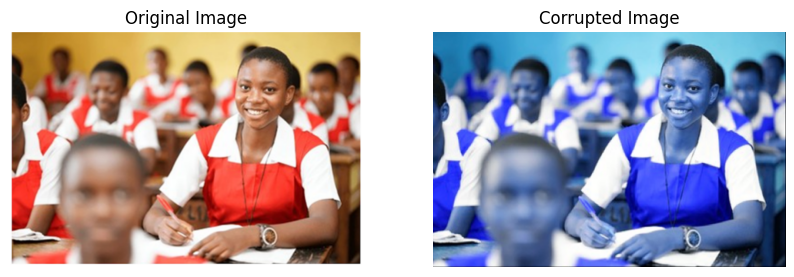

In [3]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(corrupted)
plt.title("Corrupted Image")
plt.axis("off")

plt.show()

New Image = alpha * Image + beta

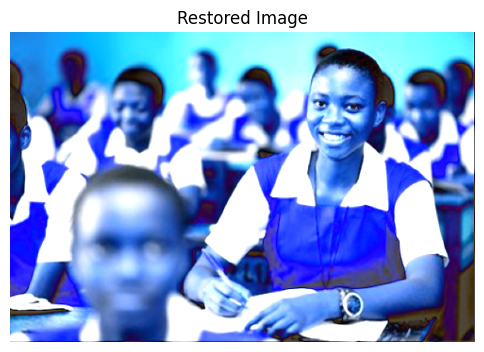

In [5]:
# Adjust brightness and contrast
alpha = 1.8   # Contrast control
beta = -80    # Brightness control

restored = cv2.convertScaleAbs(corrupted, alpha=alpha, beta=beta)

plt.figure(figsize=(6,6))
plt.imshow(restored)
plt.title("Restored Image")
plt.axis("off")
plt.show()

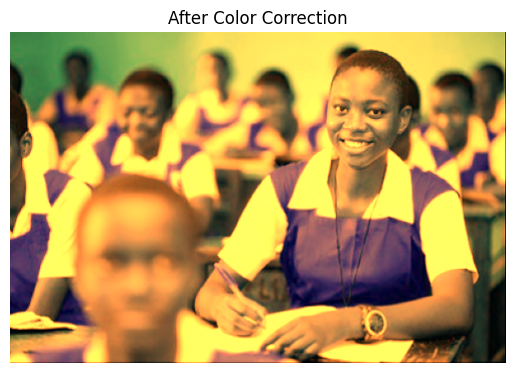

In [6]:
# Split channels
r, g, b = cv2.split(corrupted)

# Reduce blue intensity
b = cv2.multiply(b, 0.4)

# Increase red intensity
r = cv2.multiply(r, 2.2)

# Slightly boost green for natural skin tone
g = cv2.multiply(g, 1.1)

# Merge back
color_corrected = cv2.merge([r, g, b])

# Clip values to valid range
color_corrected = np.clip(color_corrected, 0, 255).astype(np.uint8)

plt.imshow(color_corrected)
plt.title("After Color Correction")
plt.axis("off")
plt.show()

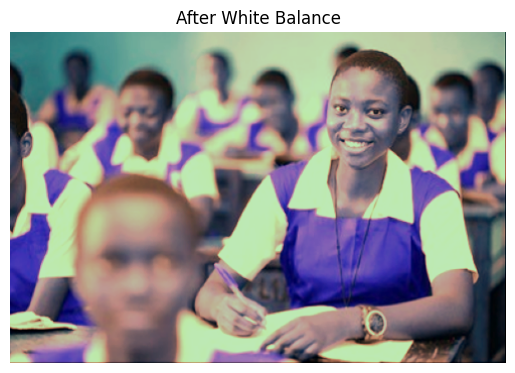

In [7]:
def white_balance(img):
    result = img.copy().astype(np.float32)

    avg_r = np.mean(result[:,:,0])
    avg_g = np.mean(result[:,:,1])
    avg_b = np.mean(result[:,:,2])

    avg_gray = (avg_r + avg_g + avg_b) / 3

    result[:,:,0] *= avg_gray / avg_r
    result[:,:,1] *= avg_gray / avg_g
    result[:,:,2] *= avg_gray / avg_b

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

balanced = white_balance(color_corrected)

plt.imshow(balanced)
plt.title("After White Balance")
plt.axis("off")
plt.show()

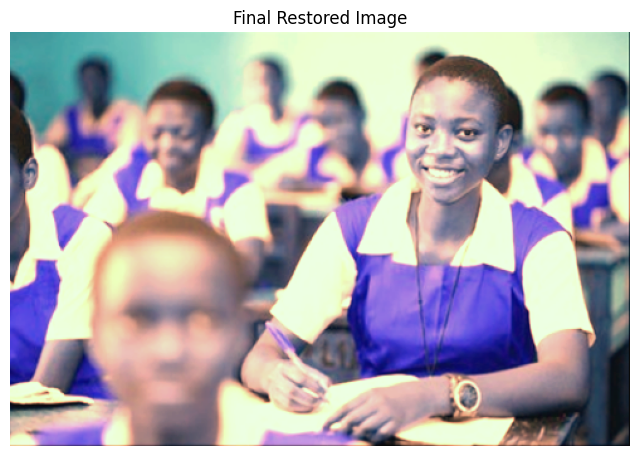

In [8]:
alpha = 1.2   # Contrast
beta = 10     # Brightness

final_restored = cv2.convertScaleAbs(balanced, alpha=alpha, beta=beta)

plt.figure(figsize=(8,6))
plt.imshow(final_restored)
plt.title("Final Restored Image")
plt.axis("off")
plt.show()

## Image Restoration Process

The corrupted image had a strong blue color cast.

To restore it:

1. Reduced the blue channel intensity.
2. Increased the red channel to restore uniform color.
3. Applied white balance using Gray World assumption.
4. Adjusted brightness and contrast.

Final Parameters Used:
Blue multiplier = 0.4  
Red multiplier = 2.2  
Green multiplier = 1.1  
Contrast (alpha) = 1.2  
Brightness (beta) = 10  

These values restored the natural skin tones and attempted to correct the uniform color from blue back to red, but it wasn't successful.